# The Enron email corpus, week four: closing the review points

**Data Mining Lab, Summer 2026 (Descriptive Mining 4 report)**

We have now finished processing the whole corpus. Every one of the 517,401
raw files has been deduplicated, body-cleaned, address-normalised and
thread-reconstructed into two parquet tables under `eda-5/clean/`; the full
procedure, with its results and limits, is written up in
`eda-5/DATASET_CLEANING.md`. This notebook is the readable summary: it reruns
the week-three analysis on that cleaned data and digs deeper where the cleaning
changes the answer.

Running on the clean tables instead of the raw cache matters, because the raw
file count was misleading in ways that touch several earlier conclusions. Half
the files were duplicate copies; one person appeared under several spellings of
their address; bodies carried the entire quoted history of every reply; and
there were no usable thread headers. After cleaning there are 252,022 distinct
messages, addresses collapse to people, bodies hold only their own text, and
conversations can be followed. Where a number here differs from the week-three
notebook, the clean number is the right one, and the difference is called out.

The review points addressed below: the misleading 24-hour activity colour
scheme; how complete the dataset really is; the social plots treating addresses
as people; groups that cycle mail among themselves; the California/EES word
charts drawn on different scales; deletion timing and topic; whether departures
drove deletion; and a new section on the conversation threads the cleaning made
available for the first time. Figures are written to `eda-5/plots/`.

In [1]:
from pathlib import Path
import re
from collections import Counter, defaultdict

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

def find_root() -> Path:
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "eda-5" / "clean" / "messages_clean.parquet").exists():
            return base
    raise FileNotFoundError("eda-5/clean not found above " + str(here))

ROOT = find_root()
PLOTS = ROOT / "eda-5" / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)
CLEAN = ROOT / "eda-5" / "clean"

# The cleaned, deduplicated dataset. One row per unique message / per delivery.
msg = pd.read_parquet(CLEAN / "messages_clean.parquet")
rcp = pd.read_parquet(CLEAN / "recipients_clean.parquet")

# datable subset for the time-series and rhythm plots
mt = msg[msg["date_plausible"] & msg["date"].notna()].copy()
mt["year"] = mt["date"].dt.year
mt["weekday"] = mt["date"].dt.day_name()
mt["hour"] = mt["date"].dt.hour

print(f"unique messages:  {len(msg):>9,}")
print(f"datable messages: {len(mt):>9,}  ({len(mt)/len(msg):.1%})")
print(f"recipient edges:  {len(rcp):>9,}")
print(f"non-empty bodies: {int((msg['body_chars']>0).sum()):>9,}")

# Collapse-timeline markers reused on the time-series plots below.
EVENTS = [("2001-08-14", "Skilling quits"),
          ("2001-10-16", "Q3 loss"),
          ("2001-11-08", "restatement"),
          ("2001-12-02", "Chapter 11 + layoffs")]
SCANDAL_START = pd.Timestamp("2001-08-14")
SCANDAL_END = pd.Timestamp("2002-06-30")
SCANDAL_COLOR = "#d04545"
SCANDAL_ALPHA = 0.12

unique messages:    252,022
datable messages:   251,666  (99.9%)
recipient edges:  1,372,596
non-empty bodies:   233,010


## A. The 24-hour activity plot, fixed

The week-three weekday-by-hour heatmap drew all four years on a single colour
bar, but the values it coloured were each year's own percentage shares rather
than message counts, and the colour map ran from dark at zero to bright at the
top. Two things went wrong. Because the shared scale was fixed by the single
busiest cell in any year, the low-volume years (1999 and 2000) came out almost
uniformly dark and read as empty, when their working rhythm is perfectly clear
once they are allowed their own range. And a dark-for-zero map makes an empty
grid look busy, since the eye reads the dark background as filled.

The fix is to stop asking one picture to answer two questions, and to colour
empty cells white. The top row, in blue, uses one shared scale of real message
counts, which is honest about how much larger 2001 is. The bottom row, in green,
rescales each year to its own busiest hour, which is honest about the shape of
the day. The two rows use different colour maps precisely so they are never
mistaken for the same scale, and on both a blank cell is white.

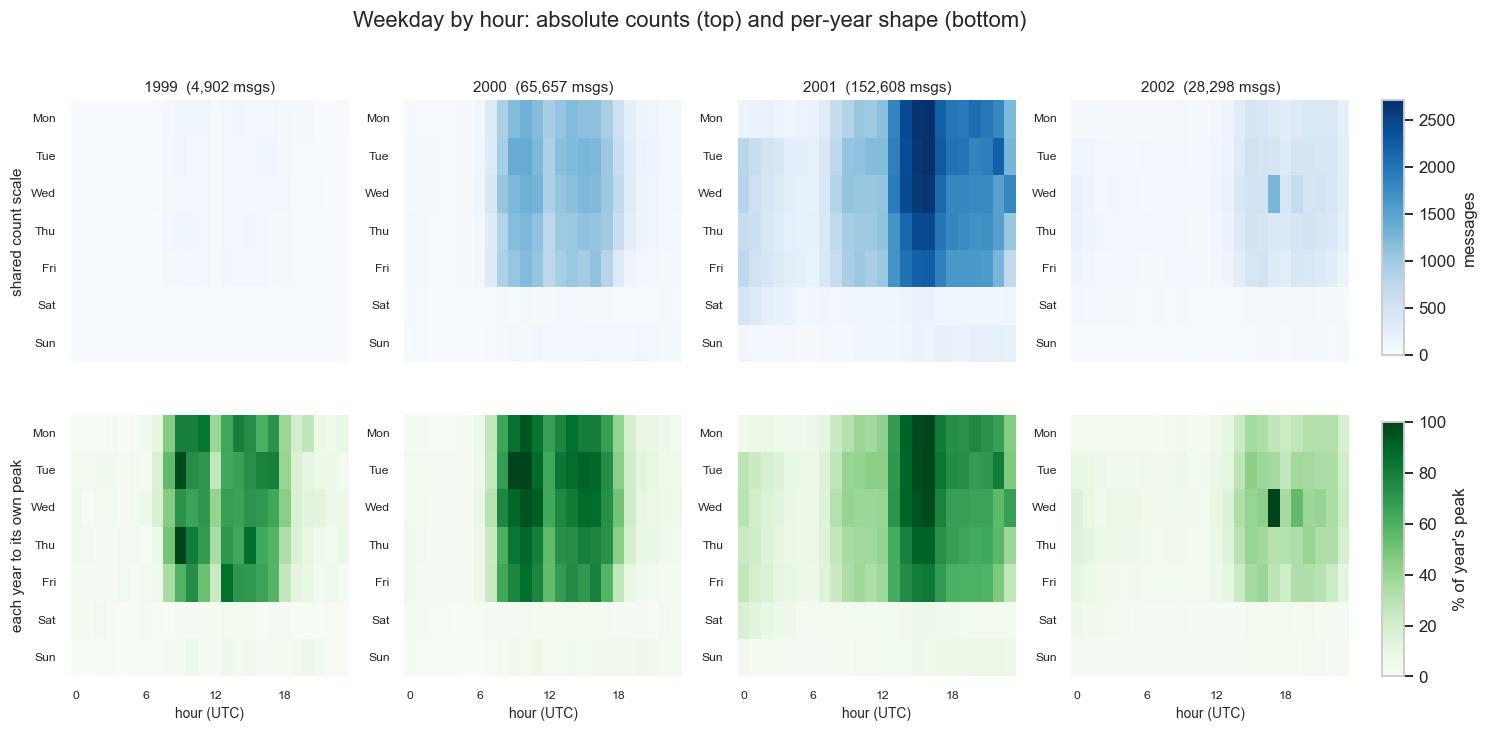

In [2]:
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday",
            "Friday", "Saturday", "Sunday"]
years_to_plot = [1999, 2000, 2001, 2002]

counts = {}
for y in years_to_plot:
    sub = mt[mt["year"] == y]
    tab = (sub.groupby(["weekday", "hour"]).size()
              .unstack(fill_value=0).reindex(weekdays)
              .reindex(columns=range(24), fill_value=0))
    counts[y] = tab

abs_vmax = max(t.values.max() for t in counts.values())
cmap_top = "Blues"
cmap_bot = "Greens"
fig, axes = plt.subplots(2, 4, figsize=(15, 6.8))

for ax, y in zip(axes[0], years_to_plot):
    sns.heatmap(counts[y], ax=ax, cmap=cmap_top, vmin=0, vmax=abs_vmax,
                cbar=False, linewidths=0)
    ax.set_title(f"{y}  ({counts[y].values.sum():,} msgs)", fontsize=10)
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.set_yticks(np.arange(7) + 0.5)
    ax.set_yticklabels([w[:3] for w in weekdays], rotation=0, fontsize=8)
    ax.set_ylabel("")
axes[0, 0].set_ylabel("shared count scale", fontsize=10)

for ax, y in zip(axes[1], years_to_plot):
    t = counts[y].astype(float)
    peak = t.values.max()
    norm = t / peak * 100 if peak else t
    sns.heatmap(norm, ax=ax, cmap=cmap_bot, vmin=0, vmax=100, cbar=False, linewidths=0)
    ax.set_xticks(np.arange(0, 24, 6) + 0.5)
    ax.set_xticklabels(range(0, 24, 6), fontsize=8)
    ax.set_xlabel("hour (UTC)", fontsize=9)
    ax.set_yticks(np.arange(7) + 0.5)
    ax.set_yticklabels([w[:3] for w in weekdays], rotation=0, fontsize=8)
    ax.set_ylabel("")
axes[1, 0].set_ylabel("each year to its own peak", fontsize=10)

fig.subplots_adjust(right=0.9)
cax1 = fig.add_axes([0.92, 0.54, 0.013, 0.34])
fig.colorbar(plt.cm.ScalarMappable(cmap=cmap_top,
             norm=mpl.colors.Normalize(0, abs_vmax)), cax=cax1).set_label("messages")
cax2 = fig.add_axes([0.92, 0.11, 0.013, 0.34])
fig.colorbar(plt.cm.ScalarMappable(cmap=cmap_bot,
             norm=mpl.colors.Normalize(0, 100)), cax=cax2).set_label("% of year's peak")

fig.suptitle("Weekday by hour: absolute counts (top) and per-year shape (bottom)", y=1.0)
fig.savefig(PLOTS / "a1_weekday_hour_dual.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** The top row makes the volume gap plain: 2001 is darker
everywhere because it simply holds more mail, and 1999 is pale not because it
was idle but because it is a tenth the size. The bottom row, where each year
sets its own scale, shows that the daily shape is the same story every year:
a single weekday block from roughly 14:00 to 23:00 UTC, which is mid-morning
to late afternoon in Houston (UTC-6 in winter, UTC-5 in summer). Weekends are
white in every panel. The only year that breaks the mould is 2002, whose
weekday block is thinner and shifted, a tail of activity in a company that by
then was mostly being wound down.

## B. How complete is the dataset?

The review asked a fair question that the earlier notebooks skipped: when we
say the corpus has 517,401 messages, how many distinct e-mails is that really,
how large are they, what time span do they cover, and which header fields can
we actually trust? The four plots below answer those in turn. The short version
is that the file count badly overstates the number of distinct messages, the
timing and identity headers are reliable while the threading headers are gone,
and the 150 released mailboxes are a keyhole onto a much larger correspondence.

files on disk:          517,401
distinct messages:      252,022  (48.7%)
redundant copies:       265,379  (51.3%)
  within one mailbox:   202,735
  across mailboxes:      62,644


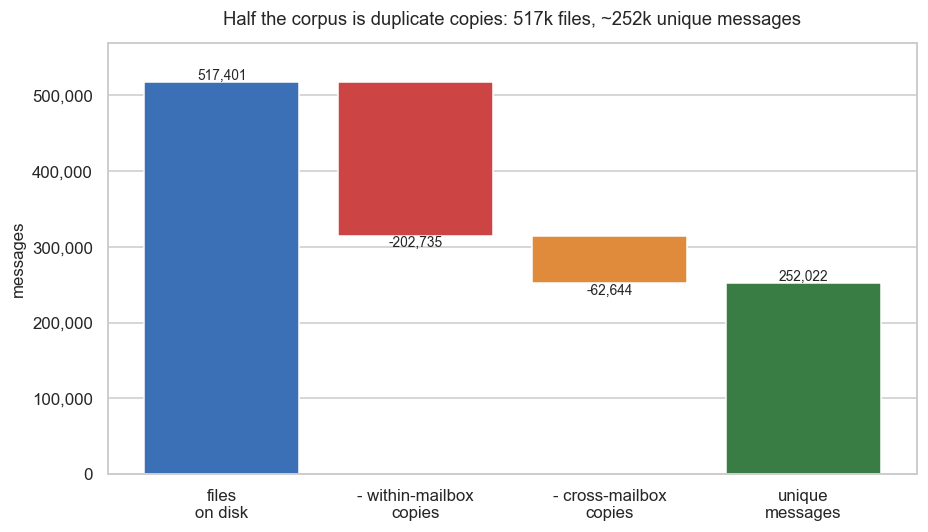

In [3]:
# Reconstruct the file<->message ratio from the clean table: every message
# records how many raw files it stood for (n_copies) and across how many
# mailboxes (n_mailboxes). Within-mailbox copies are extra files of a message
# seen in a single mailbox; cross-mailbox copies are the rest.
distinct = len(msg)
N = int(msg["n_copies"].sum())
extra = msg["n_copies"] - 1
extra_cross = int(extra[msg["n_mailboxes"] > 1].sum())
extra_within = int(extra[msg["n_mailboxes"] == 1].sum())

print(f"files on disk:        {N:>9,}")
print(f"distinct messages:    {distinct:>9,}  ({distinct/N:.1%})")
print(f"redundant copies:     {N-distinct:>9,}  ({(N-distinct)/N:.1%})")
print(f"  within one mailbox: {extra_within:>9,}")
print(f"  across mailboxes:   {extra_cross:>9,}")

fig, ax = plt.subplots(figsize=(8.6, 5))
steps = [("files\non disk", N, "#3b6fb6", True),
         ("- within-mailbox\ncopies", -extra_within, "#c44", False),
         ("- cross-mailbox\ncopies", -extra_cross, "#e08a3c", False),
         ("unique\nmessages", distinct, "#3a7d44", True)]
running = 0
for i, (labl, val, col, absolute) in enumerate(steps):
    if absolute:
        ax.bar(i, val, color=col)
        ax.text(i, val, f"{val:,}", ha="center", va="bottom", fontsize=9)
        running = val
    else:
        ax.bar(i, val, bottom=running, color=col)
        ax.text(i, running + val, f"{val:,}", ha="center", va="top", fontsize=9)
        running += val
ax.set_xticks(range(len(steps)))
ax.set_xticklabels([s[0] for s in steps])
ax.set_ylabel("messages")
ax.set_ylim(0, N * 1.10)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_title("Half the corpus is duplicate copies: 517k files, ~252k unique messages",
             pad=12)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
fig.tight_layout()
fig.savefig(PLOTS / "b1_dedup_waterfall.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** Two files count as the same message when they share a
sender, a subject, an exact send time, and recipient counts. By that test only
252,022 of the 517,401 files are distinct, so 51% of the corpus is duplication.
Most of it, about 203,000 copies, is within a single mailbox: the same message
filed in both the inbox and a project folder, a common Outlook habit. The rest,
about 63,000 copies, is the same message sitting in several people's mailboxes
because they were all on it. Every count in this notebook is computed on the
252,022 distinct messages; the raw file count would have inflated broadcasts
and carefully filed memos many times over.

### B.1 What dedup changes: folder mix and mailbox ranking

Two week-three statements were artifacts of counting files instead of messages,
and dedup overturns both. The first is the folder mix. The week-two report said
project and topic folders were the largest block of the corpus at 37%. They are
not: those folders are where people re-file copies of mail they already hold in
`inbox` or `sent`, so they carry far more than their share of the duplicates.
Once each message is counted once, `topic/project` collapses from 37% to about
11% and `sent` plus `inbox` become the real bulk of the corpus.

The second is mailbox size. The week-two 'largest mailbox' was `kaminski-v` at
28,465 files; after dedup the largest is `dasovich-j`, and `kaminski-v` drops to
second. The per-mailbox duplication rate ranges from near zero to almost
everything, so raw file counts do not even rank people correctly.

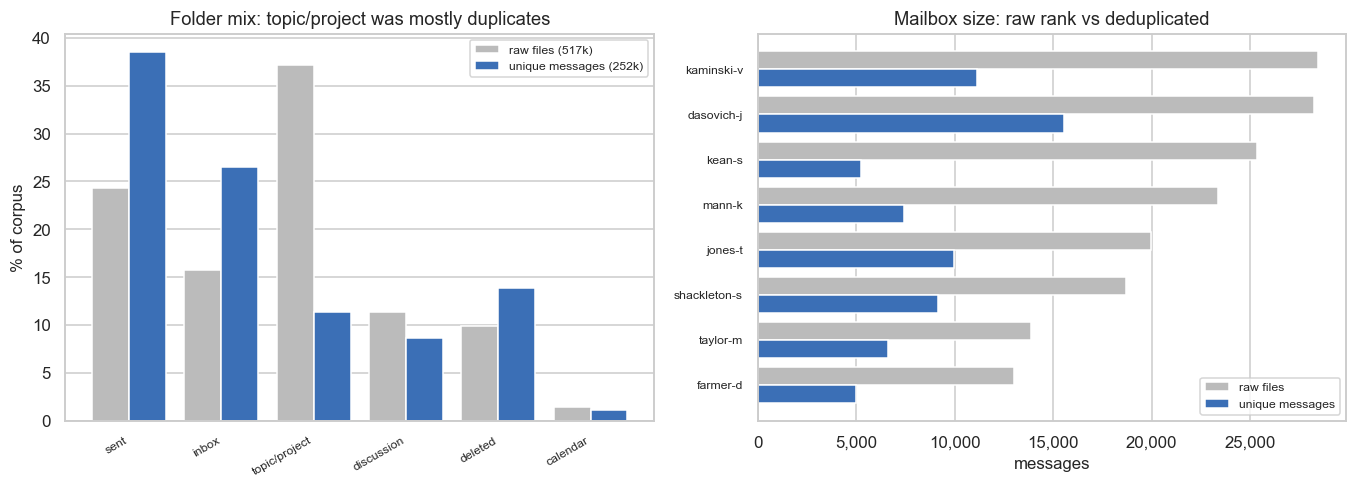

folder mix (raw % -> clean %):
  sent            24.4 ->  38.5
  inbox           15.8 ->  26.5
  topic/project   37.1 ->  11.3
  discussion      11.3 ->   8.6
  deleted          9.9 ->  13.9
  calendar         1.5 ->   1.2


In [4]:
# For this one comparison we need the true raw per-file distribution, which
# the clean table cannot reconstruct (it keeps one canonical folder per
# message). Read the original folder labels from the week-two cache just to
# draw the before picture; everything else in the notebook stays on clean data.
order = ["sent", "inbox", "topic/project", "discussion", "deleted", "calendar"]
raw_rich = pd.read_parquet(ROOT / "eda-2" / "cache" / "rich_header_features.parquet",
                           columns=["user", "folder_group"])
raw_fg = (raw_rich["folder_group"].value_counts().reindex(order) / len(raw_rich) * 100)
cln_fg = (msg["folder_group"].value_counts().reindex(order) / len(msg) * 100)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
x = np.arange(len(order)); w = 0.4
axes[0].bar(x - w/2, raw_fg.values, w, label="raw files (517k)", color="#bbb")
axes[0].bar(x + w/2, cln_fg.values, w, label="unique messages (252k)", color="#3b6fb6")
axes[0].set_xticks(x); axes[0].set_xticklabels(order, rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("% of corpus")
axes[0].set_title("Folder mix: topic/project was mostly duplicates")
axes[0].legend(fontsize=8); axes[0].grid(axis="x", visible=False)

raw_rank = raw_rich["user"].value_counts().head(8)
cln_rank = msg["mailbox_owner"].value_counts().reindex(raw_rank.index)
y = np.arange(len(raw_rank))[::-1]
axes[1].barh(y + 0.2, raw_rank.values, 0.4, label="raw files", color="#bbb")
axes[1].barh(y - 0.2, cln_rank.values, 0.4, label="unique messages", color="#3b6fb6")
axes[1].set_yticks(y); axes[1].set_yticklabels(raw_rank.index, fontsize=8)
axes[1].set_xlabel("messages"); axes[1].set_title("Mailbox size: raw rank vs deduplicated")
axes[1].legend(fontsize=8); axes[1].grid(axis="y", visible=False)
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{int(v):,}"))
fig.tight_layout()
fig.savefig(PLOTS / "b1b_dedup_corrections.png", dpi=140, bbox_inches="tight")
plt.show()

print("folder mix (raw % -> clean %):")
for f in order:
    print(f"  {f:14} {raw_fg[f]:5.1f} -> {cln_fg[f]:5.1f}")

**What it shows.** The left panel makes the folder-mix inversion concrete: grey
bars (raw files) put `topic/project` on top, blue bars (unique messages) flatten
it and lift `sent` and `inbox`. The right panel shows the same effect on people:
the mailboxes shrink by very different amounts, so the order changes and the
raw 'biggest mailbox' loses the title. Every per-folder and per-person number in
the rest of this notebook is on the deduplicated counts.

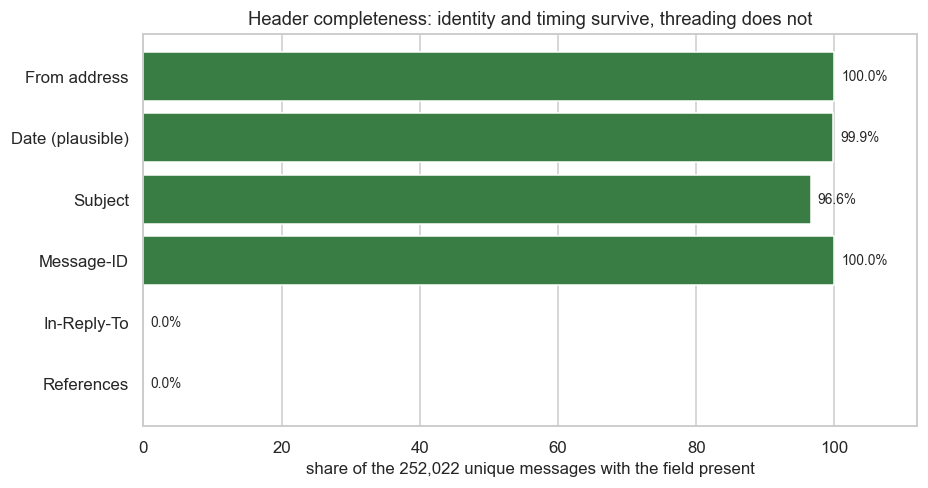

Message-ID is present on every file, but every value is a synthetic
'<...JavaMail.evans@thyme>' string minted when the corpus was processed,
so it identifies a file, not a real mail thread. In-Reply-To and
References are absent everywhere, so reply chains cannot be rebuilt from
headers; the earlier notebooks fell back on normalised subjects instead.


In [5]:
cov = pd.Series({
    "From address": (msg["from_addr"].fillna("") != "").mean(),
    "Date (plausible)": msg["date_plausible"].mean(),
    "Subject": (msg["subject"].fillna("").str.strip() != "").mean(),
    "Message-ID": (msg["message_id"].fillna("") != "").mean(),
    "In-Reply-To": 0.0,
    "References": 0.0,
}) * 100

fig, ax = plt.subplots(figsize=(8.6, 4.6))
colors = ["#3a7d44" if v > 50 else "#c44" for v in cov.values]
ax.barh(cov.index[::-1], cov.values[::-1], color=colors[::-1])
for i, v in enumerate(cov.values[::-1]):
    ax.text(min(v + 1, 101), i, f"{v:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, 112)
ax.set_xlabel("share of the 252,022 unique messages with the field present")
ax.set_title("Header completeness: identity and timing survive, threading does not")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
fig.tight_layout()
fig.savefig(PLOTS / "b2_metadata_coverage.png", dpi=140, bbox_inches="tight")
plt.show()

print("Message-ID is present on every file, but every value is a synthetic")
print("'<...JavaMail.evans@thyme>' string minted when the corpus was processed,")
print("so it identifies a file, not a real mail thread. In-Reply-To and")
print("References are absent everywhere, so reply chains cannot be rebuilt from")
print("headers; the earlier notebooks fell back on normalised subjects instead.")

**What it shows.** The fields needed to say who sent what, and when, are all
but complete: a sender on every file, a usable timestamp on 99.9%, a non-empty
subject on 96%. The fields needed to reconstruct conversations are simply not
there. Message-ID looks present at 100%, but the values are machine-generated
placeholders with no link to the messages they reply to, and In-Reply-To and
References were stripped before release. That is the single biggest gap in the
data: the corpus knows every message but not which message answered which.

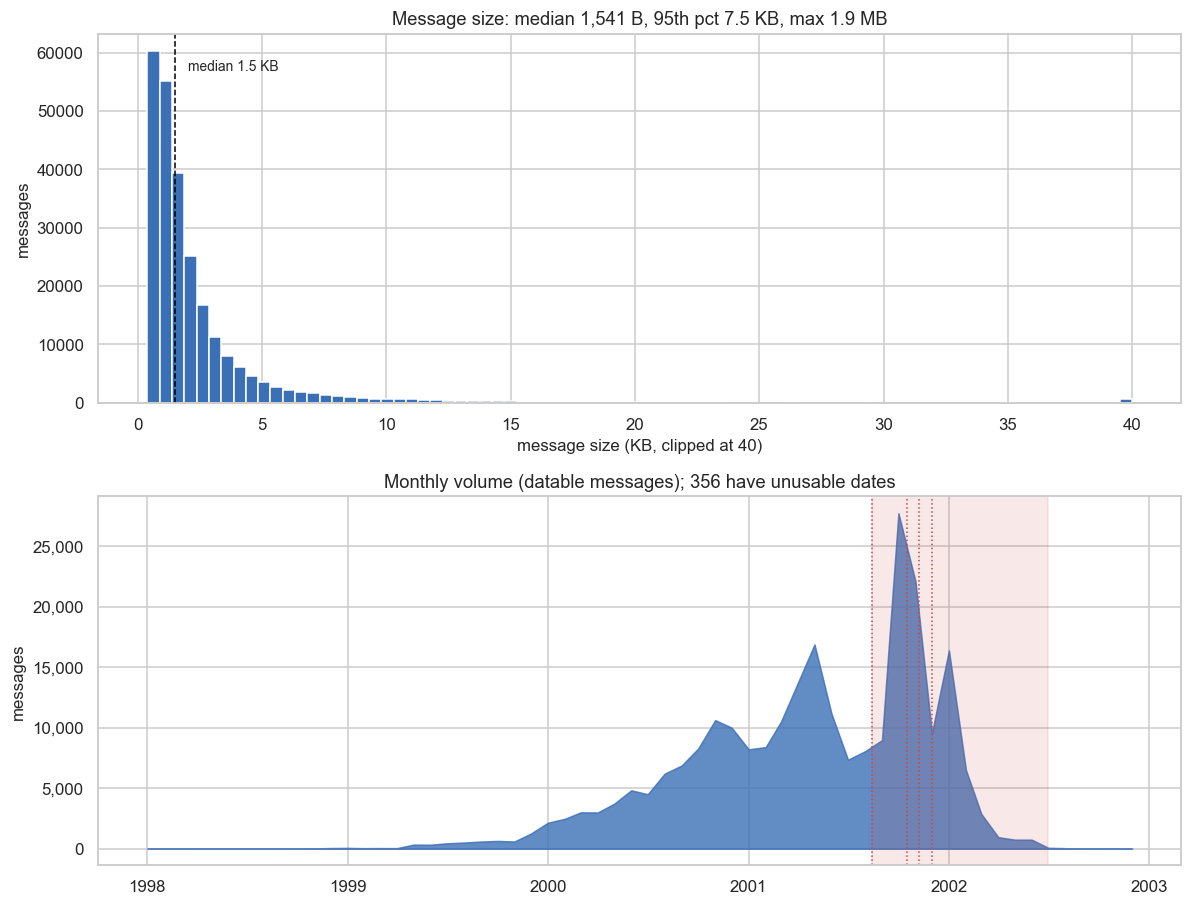

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8.4))

kb = msg["file_size"] / 1024
axes[0].hist(kb.clip(upper=40), bins=80, color="#3b6fb6")
axes[0].axvline(kb.median(), color="black", ls="--", lw=1)
axes[0].text(kb.median() + 0.5, axes[0].get_ylim()[1] * 0.9,
             f"median {msg['file_size'].median()/1024:.1f} KB", fontsize=9)
axes[0].set_xlabel("message size (KB, clipped at 40)")
axes[0].set_ylabel("messages")
axes[0].set_title(f"Message size: median {int(msg['file_size'].median()):,} B, "
                  f"95th pct {kb.quantile(.95):.1f} KB, max {kb.max()/1024:.1f} MB")

mv = mt.groupby(mt["date"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()).size()
mv = mv[(mv.index >= pd.Timestamp("1998-01-01")) & (mv.index <= pd.Timestamp("2002-12-31"))]
axes[1].fill_between(mv.index, mv.values, color="#3b6fb6", alpha=0.8)
axes[1].axvspan(SCANDAL_START, SCANDAL_END, color=SCANDAL_COLOR, alpha=SCANDAL_ALPHA)
for d, _ in EVENTS:
    axes[1].axvline(pd.Timestamp(d), color=SCANDAL_COLOR, lw=1, ls=":")
axes[1].set_ylabel("messages")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[1].set_title(f"Monthly volume (datable messages); {len(msg)-len(mt)} have unusable dates")
fig.tight_layout()
fig.savefig(PLOTS / "b3_size_and_timespan.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** Messages are small. The median file is about 1.5 KB, the
95th percentile is under 8 KB, and the long tail up to roughly 2 MB is the
handful of mails carrying large quoted threads or inline tables. On the time
axis the usable mail runs from 1999 to the end of 2002, with the familiar
build-up through 2000 and the spike around the autumn-2001 collapse. Only 605
files (0.1%) carry a date the parser could not trust, most of them stamped
1 January 1980, the zero point a mail client falls back to when the real date
is missing. So the timeline is essentially complete, with a known and tiny
hole rather than a silent one.

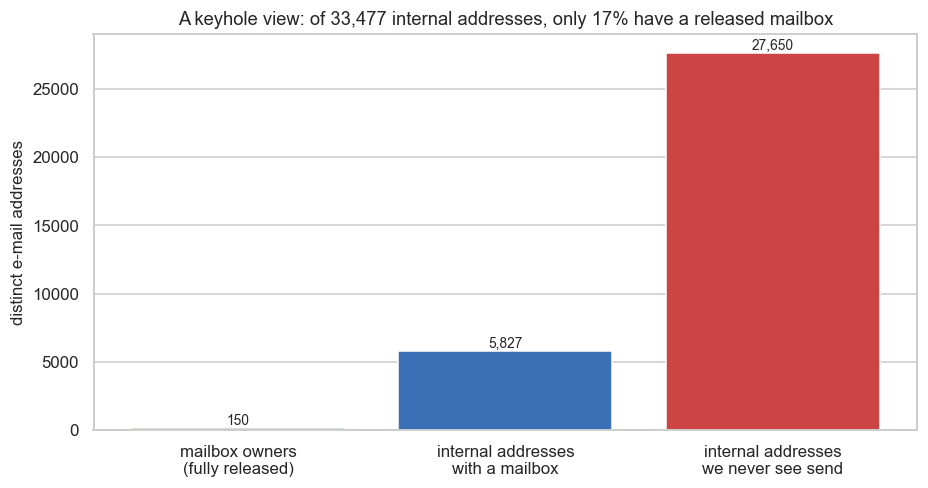

distinct senders seen:    20,312
distinct recipients seen: 77,779
internal recipients:      33,477
  of those with a mailbox:5,827 (17.4%)


In [7]:
distinct_senders = msg["from_addr_norm"].replace("", np.nan).nunique()
distinct_recip = rcp["recipient_addr_norm"].replace("", np.nan).nunique()
senders_set = set(msg["from_addr_norm"].dropna().unique()) - {""}
int_recip_set = set(rcp.loc[rcp["is_internal_recipient"], "recipient_addr_norm"].dropna().unique()) - {""}
int_recip = len(int_recip_set)
int_covered = len(int_recip_set & senders_set)

cats = ["mailbox owners\n(fully released)", "internal addresses\nwith a mailbox",
        "internal addresses\nwe never see send"]
vals = [150, int_covered, int_recip - int_covered]
fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.bar(cats, vals, color=["#3a7d44", "#3b6fb6", "#c44"])
for i, v in enumerate(vals):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("distinct e-mail addresses")
ax.set_title(f"A keyhole view: of {int_recip:,} internal addresses, only "
             f"{int_covered/int_recip:.0%} have a released mailbox")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
fig.tight_layout()
fig.savefig(PLOTS / "b4_recipient_coverage.png", dpi=140, bbox_inches="tight")
plt.show()

print(f"distinct senders seen:    {distinct_senders:,}")
print(f"distinct recipients seen: {distinct_recip:,}")
print(f"internal recipients:      {int_recip:,}")
print(f"  of those with a mailbox:{int_covered:,} ({int_covered/int_recip:.1%})")

**What it shows.** The corpus is built from 150 fully captured mailboxes, but
those 150 people wrote to and heard from far more. Counting only Enron-internal
addresses (normalised, so spelling variants do not inflate the count), about
33,000 distinct accounts appear as recipients, and only about 17% of them have
a mailbox of their own in the release. For the rest we see one side of the
conversation at best. This is the main caveat for
every network result in these notebooks: the graph is dense and complete among
the 150, and increasingly partial as it reaches everyone else. It is a keyhole
onto Enron's mail, not the whole room.

## C. Mailboxes are not people

The week-three round-trip and degree plots keyed on raw e-mail addresses. The
reviewer's point was that an address is not a person: the same individual sends
as `vince.kaminski@enron.com`, `j.kaminski@enron.com`, `vkamins@enron.com` and
so on, and these were being scattered across the plots as if they were
different people. Before redrawing anything we resolve addresses to people.

The resolution is built from the data itself and then sense-checked against the
names we already collected in `WHOS_WHO.md`. Each of the 150 mailboxes is owned
by one person, so the addresses that person sends from, taken from their own
sent-mail folders, are that person's aliases as long as the surname appears in
the address. One clarification on the wording of the feedback: in this corpus a
mailbox really does equal a person. The only repeated surnames are mckay,
ring and whalley, and each pair is two different people (different first
initials, `mckay-b` and `mckay-j`, and so on). So nothing needs merging at the
folder level; the multiplicity lives entirely in the addresses.

owners with >=1 resolved address: 141 of 150
total resolved enron addresses:   185
addresses per owner: median 1, max 4 (kaminski-v)


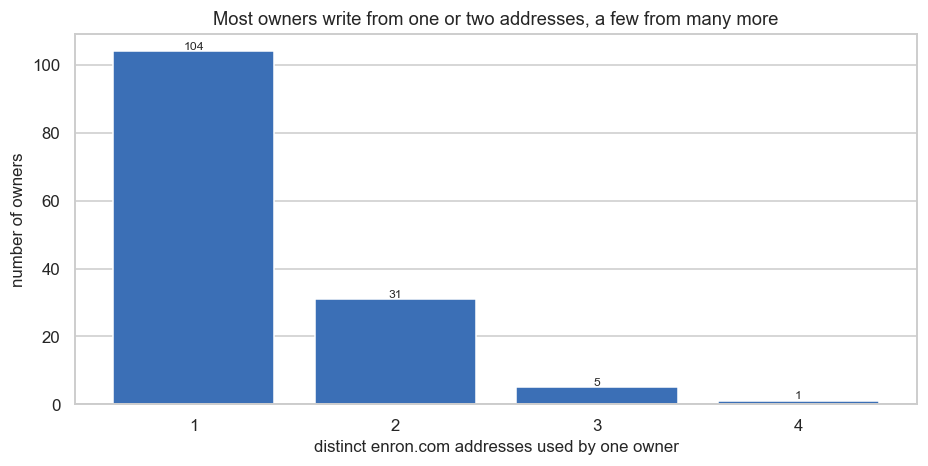


owners using the most addresses (formatting variants of one name):
  kaminski-v      4  e.g. ['j..kaminski@enron.com', 'j.kaminski@enron.com', 'kaminski@enron.com']
  ward-k          3  e.g. ['.ward@enron.com', 'kim.ward@enron.com', 's..ward@enron.com']
  haedicke-m      3  e.g. ['e..haedicke@enron.com', 'mark.e.haedicke@enron.com', 'mark.haedicke@enron.com']
  hodge-j         3  e.g. ['jeffrey.hodge@enron.com', 'john.hodge@enron.com', 't..hodge@enron.com']
  gay-r           3  e.g. ['l..gay@enron.com', 'randall.gay@enron.com', 'rob.gay@enron.com']
  taylor-m        3  e.g. ['.taylor@enron.com', 'e.taylor@enron.com', 'mark.taylor@enron.com']


In [8]:
owners = sorted(msg["mailbox_owner"].unique())
owner_surname = {u: u.split("-")[0] for u in owners}

# Each owner's distinct sending addresses, taken from their own sent mail and
# kept only when the surname appears in the local part (the conservative rule
# from the cleaning step). The raw `from_addr` shows the spelling variants; the
# normalised `from_addr_norm` is what the rest of the analysis uses.
sent = msg[msg["folder_group"].eq("sent")]
alias_of = defaultdict(set)
for u, grp in sent.groupby("mailbox_owner"):
    sn = owner_surname[u]
    addrs = grp["from_addr"].dropna()
    addrs = addrs[addrs.str.endswith("@enron.com", na=False)]
    for a in addrs.unique():
        if sn and sn in a.split("@")[0].lower():
            alias_of[u].add(a)

n_addr = pd.Series({u: len(alias_of[u]) for u in owners})
print(f"owners with >=1 resolved address: {(n_addr > 0).sum()} of {len(owners)}")
print(f"total resolved enron addresses:   {sum(len(v) for v in alias_of.values()):,}")
print(f"addresses per owner: median {int(n_addr[n_addr>0].median())}, "
      f"max {int(n_addr.max())} ({n_addr.idxmax()})")

vc = n_addr[n_addr > 0].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(vc.index, vc.values, color="#3b6fb6")
for x, yv in zip(vc.index, vc.values):
    ax.text(x, yv, str(int(yv)), ha="center", va="bottom", fontsize=8)
ax.set_xlabel("distinct enron.com addresses used by one owner")
ax.set_ylabel("number of owners")
ax.set_xticks(sorted(int(x) for x in vc.index))
ax.set_title("Most owners write from one or two addresses, a few from many more")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
fig.tight_layout()
fig.savefig(PLOTS / "c1_addresses_per_person.png", dpi=140, bbox_inches="tight")
plt.show()

print("\nowners using the most addresses (formatting variants of one name):")
for u, k in n_addr.sort_values(ascending=False).head(6).items():
    print(f"  {u:14s} {k:>2d}  e.g. {sorted(alias_of[u])[:3]}")

**What it shows.** The distribution is skewed but shallow. Of the 150 owners,
104 write from a single Enron address, 31 from two, and only six from three or
four; nine never send from an address that contains their surname at all (they
use a differently-shaped login, so the conservative rule here simply leaves them
unresolved). The few multi-address cases are not extra accounts but messy
formatting of one name: the heaviest is Vince Kaminski, whose sent mail carries
his name as `kaminski`, `j.kaminski` and `j..kaminski`. The numbers are smaller
than the raw scatter of addresses suggested, but the reviewer's point still
holds: leaving these split puts the same person in several faint rows, and the
next section collapses them so each person appears once. (This counts only the
addresses a person sends from inside the corpus; aliases they received under but
never sent from are not captured, so the true count per person is a lower bound.)

## D. Round-trips and a cluster that cycles mail, on people

With the address-to-person map in hand we can redraw the round-trip chart so
that the same person sits in one row, and then look for the structure the
reviewer asked about: a group whose members all send mail to each other rather
than just to a common hub.

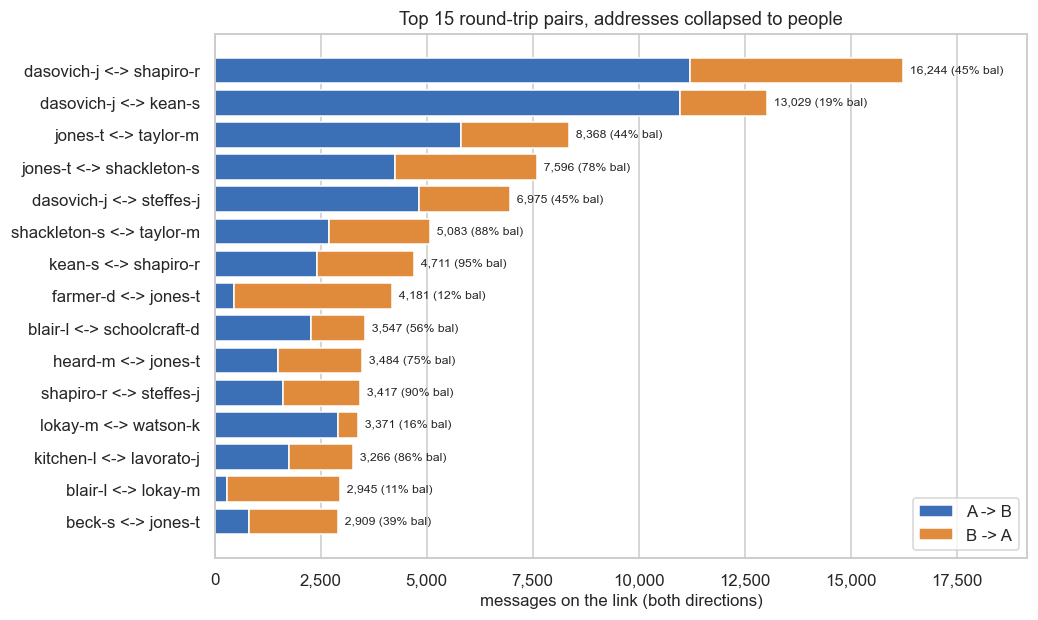

In [9]:
# People-level internal edges from the clean recipient table: To-channel,
# internal->internal, distribution lists and self-mail removed, addresses
# already normalised so one person is one node. Each owner's mailbox maps its
# normalised sending addresses to the owner handle so the graph counts people.
o2 = msg.dropna(subset=["from_addr_norm"]).query("from_addr_norm != ''")
o2 = o2.drop_duplicates("from_addr_norm")
addr2person = dict(zip(o2["from_addr_norm"], o2["mailbox_owner"]))
def to_person(a):
    return addr2person.get(a, a)

ei = rcp.merge(msg[["message_id", "from_addr_norm"]], on="message_id")
ei = ei[(ei["channel"] == "to") & ei["is_internal_recipient"]
        & ~ei["recipient_is_list"] & ~ei["is_self"]]
ei = ei[(ei["from_addr_norm"] != "") & (ei["recipient_addr_norm"] != "")]
ei["pf"] = ei["from_addr_norm"].map(to_person)
ei["pt"] = ei["recipient_addr_norm"].map(to_person)
ei = ei[ei["pf"] != ei["pt"]]
pcount = ei.groupby(["pf", "pt"]).size()
pset = set(pcount.index)

seen, rows = set(), []
for (a, b) in pcount.index:
    if (b, a) in pset:
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        rows.append((key[0], key[1],
                     int(pcount.get((key[0], key[1]), 0)),
                     int(pcount.get((key[1], key[0]), 0))))
rt = pd.DataFrame(rows, columns=["a", "b", "ab", "ba"])
rt["total"] = rt["ab"] + rt["ba"]
rt = rt.sort_values("total", ascending=False).head(15).reset_index(drop=True)

def short(x):
    return x if "@" not in x else x.split("@")[0]
labels = [f"{short(a)} <-> {short(b)}" for a, b in zip(rt["a"], rt["b"])]
fig, ax = plt.subplots(figsize=(9.6, 5.8))
y = np.arange(len(rt))[::-1]
ax.barh(y, rt["ab"], color="#3b6fb6", label="A -> B")
ax.barh(y, rt["ba"], left=rt["ab"], color="#e08a3c", label="B -> A")
ax.set_yticks(y)
ax.set_yticklabels(labels)
for yy, t, ab, ba in zip(y, rt["total"], rt["ab"], rt["ba"]):
    r = min(ab, ba) / max(ab, ba) if max(ab, ba) else 0
    ax.text(t, yy, f"  {t:,} ({r:.0%} bal)", va="center", fontsize=8)
ax.set_xlabel("messages on the link (both directions)")
ax.set_xlim(0, rt["total"].max() * 1.18)
ax.set_title("Top 15 round-trip pairs, addresses collapsed to people")
ax.legend(loc="lower right")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
fig.tight_layout()
fig.savefig(PLOTS / "d1_roundtrip_people.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** Collapsing addresses to people tightens the picture. Each
pair is now one row no matter how many address spellings the two used, and the
balance figure (the smaller direction as a share of the larger) shows whether a
link is genuinely two-way. The heaviest links are the California
government-affairs pairs around Jeff Dasovich (Dasovich with Richard Shapiro
and Steve Kean at the top) and the ENA legal pairs (Tana Jones with Mark Taylor
and Sara Shackleton). One caveat the balance column makes visible: the very
largest links are not all balanced, so a high total can still be one heavy
sender plus a lighter reply stream rather than an even exchange.

reciprocal people-graph: 150 nodes, 4768 edges
densest layer: the 50-core; largest clique: 36 people


communities: 5 (sizes [56, 36, 29, 18, 11])


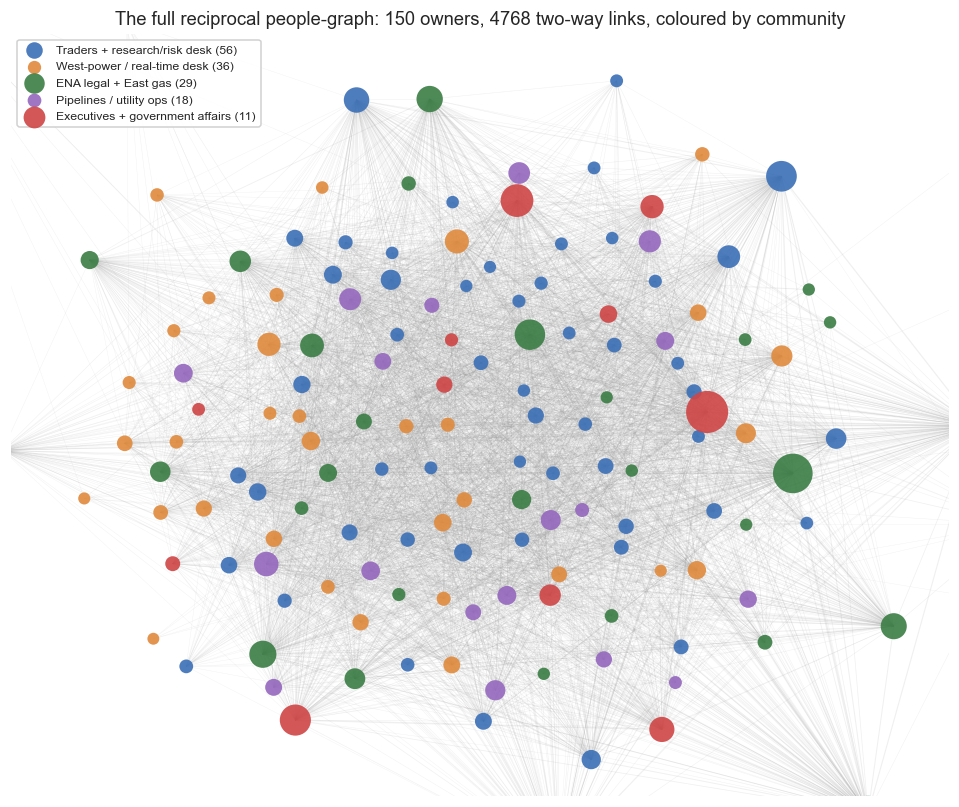

In [10]:
import networkx as nx

people = set(owners)
G = nx.Graph()
for (a, b), c in pcount.items():
    if a in people and b in people and (b, a) in pset and not G.has_edge(a, b):
        G.add_edge(a, b, weight=int(c + pcount.get((b, a), 0)))
print(f"reciprocal people-graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

kmax = max(nx.core_number(G).values())
biggest = max(nx.find_cliques(G), key=len)
print(f"densest layer: the {kmax}-core; largest clique: {len(biggest)} people")

# Split the graph into communities (greedy modularity) so the hairball can be
# read as a handful of working groups rather than one tangle.
comms = sorted(nx.community.greedy_modularity_communities(G, weight="weight"),
               key=len, reverse=True)
comm_of = {n: i for i, com in enumerate(comms) for n in com}
# hand-read labels for the five communities (by their senior/recognisable members)
COMM_LABELS = ["Traders + research/risk desk",
               "West-power / real-time desk",
               "ENA legal + East gas",
               "Pipelines / utility ops",
               "Executives + government affairs"]
PAL = ["#3b6fb6", "#e08a3c", "#3a7d44", "#9467bd", "#d04545",
       "#17becf", "#8c564b", "#bcbd22"]
print(f"communities: {len(comms)} (sizes {[len(c) for c in comms]})")

deg = dict(G.degree(weight="weight"))
dmax = max(deg.values())
# Lay out the densely-tied part of the graph (people with >=3 reciprocal
# partners) with Kamada-Kawai; the handful of one- or two-link owners are
# pinned in a margin column so they do not stretch the core into a sliver.
udeg = dict(G.degree())
core_nodes = [n for n in G.nodes if udeg[n] >= 3]
Gc = G.subgraph(core_nodes)
pos = nx.kamada_kawai_layout(Gc, weight="weight")
xs = np.array([p[0] for p in pos.values()]); ys = np.array([p[1] for p in pos.values()])
margin = [n for n in G.nodes if n not in pos]
for j, n in enumerate(margin):
    pos[n] = np.array([xs.max() + 0.35, ys.max() - j * (np.ptp(ys) / max(len(margin), 1))])
ws = np.array([d["weight"] for *_, d in G.edges(data=True)])

fig, ax = plt.subplots(figsize=(11, 9))
nx.draw_networkx_edges(G, pos, ax=ax, width=0.2 + 1.6 * np.sqrt(ws / ws.max()),
                       alpha=0.15, edge_color="#999999")
for i, com in enumerate(comms):
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=list(com),
                           node_color=PAL[i % len(PAL)],
                           node_size=[60 + 700 * (deg[n] / dmax) for n in com],
                           alpha=0.9, linewidths=0,
                           label=f"{COMM_LABELS[i] if i < len(COMM_LABELS) else 'group ' + str(i+1)} ({len(com)})")
ax.legend(loc="upper left", fontsize=8, framealpha=0.9, markerscale=0.7)
ax.set_title(f"The full reciprocal people-graph: {G.number_of_nodes()} owners, "
             f"{G.number_of_edges()} two-way links, coloured by community")
# clip the view to where the bulk of nodes sit (2nd-98th percentile), so a few
# far-flung weak ties cannot shrink the dense centre into a blob
cx = np.array([pos[n][0] for n in core_nodes]); cy = np.array([pos[n][1] for n in core_nodes])
x0, x1 = np.percentile(cx, [2, 98]); y0, y1 = np.percentile(cy, [2, 98])
padx = (x1 - x0) * 0.10; pady = (y1 - y0) * 0.10
ax.set_xlim(x0 - padx, x1 + padx)
ax.set_ylim(y0 - pady, y1 + pady)
ax.set_axis_off()
fig.savefig(PLOTS / "d2_reciprocal_cluster.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** The whole reciprocal graph at once: every node is one of the
150 owners, every line a link where the two people mail each other in both
directions, node size is total two-way volume, and colour is the community a
modularity split assigns. It is dense, which is the headline finding, but it is
not structureless: five groups separate out, and they line up with real parts
of the company. The next figure draws each group on its own so the membership
is legible.

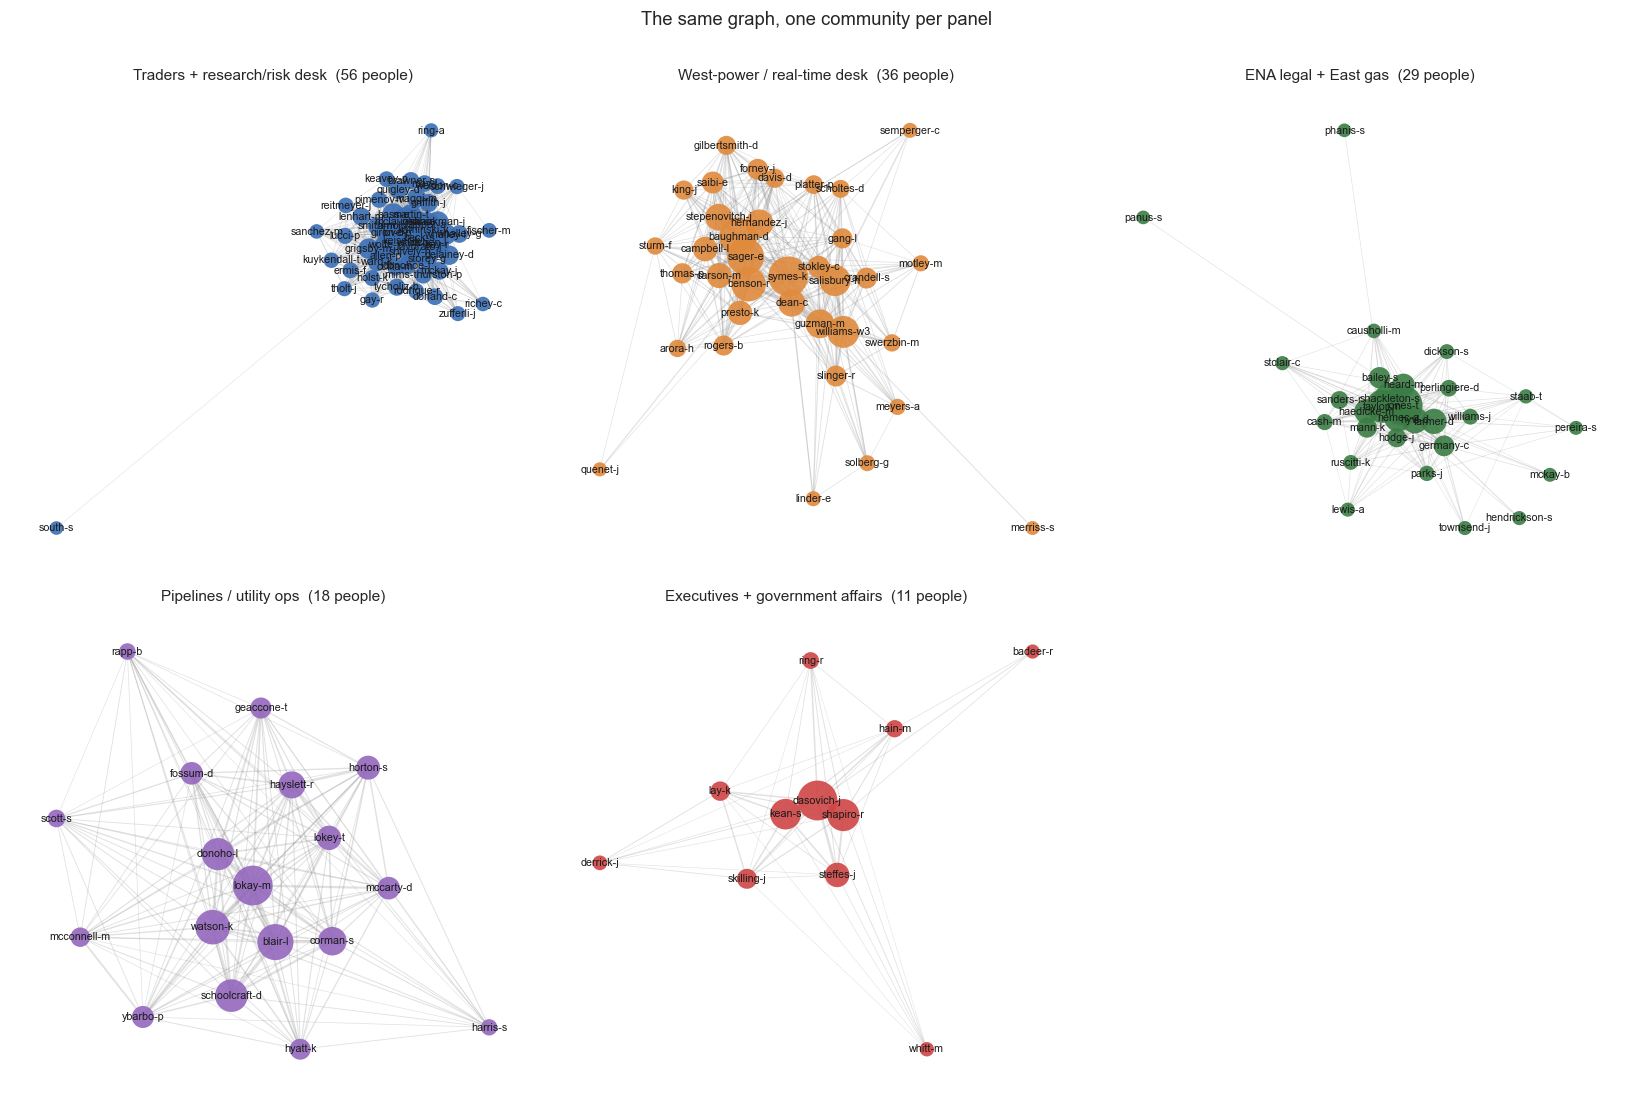

Traders + research/risk desk (56): allen-p, arnold-j, bass-e, beck-s, brawner-s, buy-r, cuilla-m, delainey-d, donohoe-t, dorland-c ...
West-power / real-time desk (36): arora-h, baughman-d, benson-r, campbell-l, carson-m, crandell-s, davis-d, dean-c, forney-j, gang-l ...
ENA legal + East gas (29): bailey-s, cash-m, causholli-m, dickson-s, farmer-d, germany-c, haedicke-m, heard-m, hendrickson-s, hodge-j ...
Pipelines / utility ops (18): blair-l, corman-s, donoho-l, fossum-d, geaccone-t, harris-s, hayslett-r, horton-s, hyatt-k, lokay-m ...
Executives + government affairs (11): badeer-r, dasovich-j, derrick-j, hain-m, kean-s, lay-k, ring-r, shapiro-r, skilling-j, steffes-j ...


In [11]:
# Each community drawn separately, with its own spring layout, so names are
# readable and the internal structure of each working group is visible.
ncom = len(comms)
ncol = 3
nrow = int(np.ceil(ncom / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 5.0 * nrow))
axes = np.atleast_1d(axes).flatten()
for i, com in enumerate(comms):
    ax = axes[i]
    sub = G.subgraph(com)
    p = nx.spring_layout(sub, seed=3, k=1.8 / np.sqrt(max(len(com), 1)), iterations=250)
    sw = np.array([d["weight"] for *_, d in sub.edges(data=True)])
    if len(sw):
        nx.draw_networkx_edges(sub, p, ax=ax, alpha=0.25, edge_color="#888888",
                               width=0.3 + 2.0 * np.sqrt(sw / sw.max()))
    sdeg = dict(sub.degree(weight="weight"))
    sdmax = max(sdeg.values()) if sdeg else 1
    nx.draw_networkx_nodes(sub, p, ax=ax, node_color=PAL[i % len(PAL)],
                           node_size=[80 + 600 * (sdeg[n] / sdmax) for n in sub.nodes],
                           alpha=0.9, linewidths=0)
    nx.draw_networkx_labels(sub, p, ax=ax, font_size=7)
    lab = COMM_LABELS[i] if i < len(COMM_LABELS) else f"group {i+1}"
    ax.set_title(f"{lab}  ({len(com)} people)", fontsize=10)
    ax.set_axis_off()
for j in range(ncom, len(axes)):
    axes[j].set_axis_off()
fig.suptitle("The same graph, one community per panel", y=1.0, fontsize=12)
fig.tight_layout()
fig.savefig(PLOTS / "d3_communities.png", dpi=140, bbox_inches="tight")
plt.show()

for i, com in enumerate(comms):
    lab = COMM_LABELS[i] if i < len(COMM_LABELS) else f"group {i+1}"
    print(f"{lab} ({len(com)}): " + ", ".join(sorted(com)[:10])
          + (" ..." if len(com) > 10 else ""))

**What it shows.** Drawn one panel at a time, the five communities are legible,
and each maps onto a real part of the company. The largest is the trading floor
with the research and risk people around it (Kaminski, Buy, Arnold, Delainey,
Beck). A second is the West-power and real-time desk (Forney, Presto, Campbell)
that ran the California positions. A third is the ENA legal department together
with the East gas desk it served (Jones, Mann, Shackleton, Haedicke, Germany,
Nemec). A fourth is the pipelines and utility-operations group (Lokay,
Hayslett, McConnell, Scott, Watson). The smallest, and the one that ties the
others together, is the executive and government-affairs core: Lay, Skilling,
Whalley sit here with Dasovich, Kean, Shapiro, Steffes and the corporate
general counsel Derrick.

Two things are worth stating plainly. The clustering is real and interpretable,
the communities are the desks and departments you would expect. But the overall
density is partly an artifact of the corpus: the 150 mailboxes were released
because these people were central to the FERC investigation, so they are far
more connected to each other than a random 150 employees would be. The graph
shows how Enron's central actors talked among themselves, not the shape of the
whole 20,000-person company.

## E. California and EES word charts, on one scale

The two co-occurrence charts in week three were drawn with independent x-axes,
so a long bar in one panel and a long bar in the other could stand for very
different counts. Put on a single shared scale they become comparable, which
is the whole point of showing them side by side.

bodies mentioning california: 12547
bodies mentioning ees:        3892


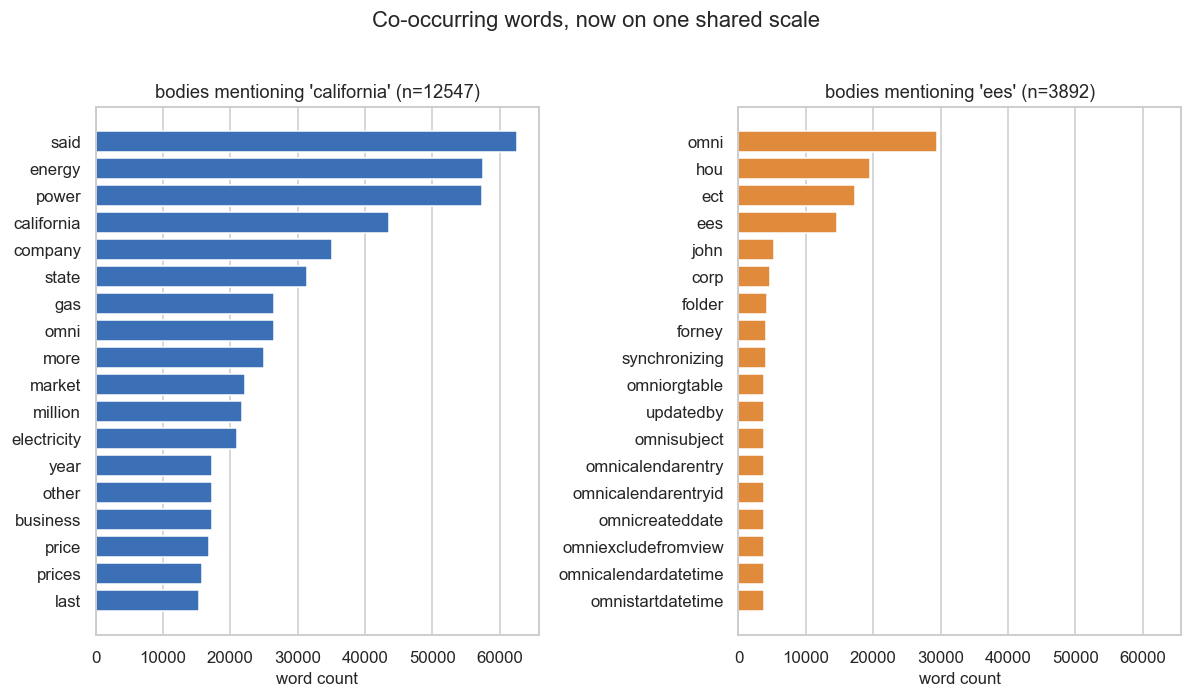

In [12]:
_STOP_RAW = ("the a an and or but if while of to for from with into out on in at by as "
             "is are was were be been being have has had do does did this that these those "
             "i you he she it we they me him her them us my your his its our their "
             "not no yes so will would shall should can could may might must "
             "about over under up down off here there what which who whom whose how why when "
             "where one two three new very also etc just only any some all per such ie eg "
             "than then http https www enron com message subject email date thanks "
             "please regards mailto re fwd hi hello call thank let know need get see "
             "original sent cc bcc pm am will would")
STOP = set(_STOP_RAW.split())
WORD = re.compile(r"[a-z][a-z']{2,}")

def topwords(series, k=18):
    c = Counter()
    for txt in series.dropna():
        for w in WORD.findall(txt.lower()):
            if w not in STOP and len(w) > 2:
                c[w] += 1
    return c.most_common(k)

# Full corpus now, not the 25k sample the week-three notebook used, and the
# bodies are cleaned, so quoted history no longer double-counts words. Exclude
# the flagged boilerplate (signatures, disclaimers) so it cannot dominate.
txt = msg.loc[~msg["body_is_boilerplate"], "body"].fillna("")
low = txt.str.lower()
cal_mask = low.str.contains(r"\bcalifornia\b", regex=True)
ees_mask = low.str.contains(r"\bees\b", regex=True)
cal_top = topwords(txt[cal_mask], 18)
ees_top = topwords(txt[ees_mask], 18)
xmax = max(max(c for _, c in cal_top), max(c for _, c in ees_top))
print(f"bodies mentioning california: {int(cal_mask.sum())}")
print(f"bodies mentioning ees:        {int(ees_mask.sum())}")

fig, axes = plt.subplots(1, 2, figsize=(11, 6.2), sharex=True)
panels = [(axes[0], cal_top, f"bodies mentioning 'california' (n={int(cal_mask.sum())})", "#3b6fb6"),
          (axes[1], ees_top, f"bodies mentioning 'ees' (n={int(ees_mask.sum())})", "#e08a3c")]
for ax, top, title, col in panels:
    words, vals = zip(*top[::-1])
    ax.barh(words, vals, color=col)
    ax.set_title(title)
    ax.set_xlim(0, xmax * 1.05)
    ax.set_xlabel("word count")
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", visible=True)
fig.suptitle("Co-occurring words, now on one shared scale", y=1.02)
fig.tight_layout()
fig.savefig(PLOTS / "e1_california_ees_samescale.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** This now runs on the whole corpus, not the 25,628-row body
sample the week-three notebook used, so the counts are an order of magnitude
larger and more stable: about 12,500 cleaned bodies mention California against
about 3,900 for EES. Because the bodies are cleaned, the words are the writers'
own and not quoted history repeated down a thread, and the flagged boilerplate
(signatures, disclaimers) is excluded so it cannot crowd the top. On a shared
scale the gap is plain: California is the far heavier topic, and its companion
words are the regulatory and power-market vocabulary of the 2000-2001 crisis
(power, energy, state, market, price). The EES panel is shorter and its words
are the internal, organisational language of the retail-services unit. Same
chart, same axis, full corpus, and now the comparison is honest.

## F. What gets deleted, and when

Week three counted deleted mail per mailbox but said nothing about timing or
content. The two plots here add both: how the volume and rate of deletion move
over the life of the company, and which subjects are more or less likely than
average to end up in a deleted folder.

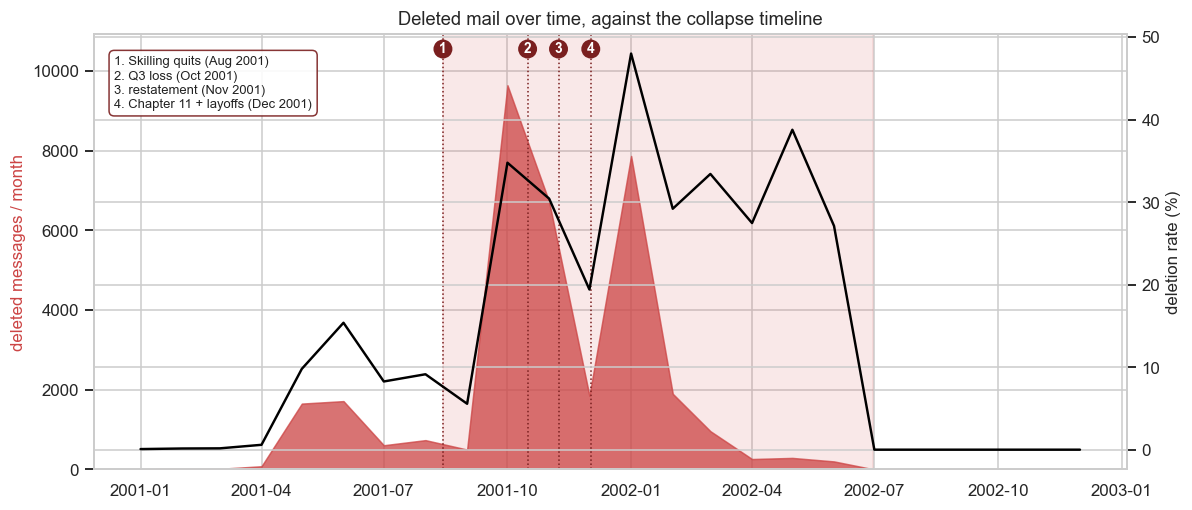

In [13]:
rt2 = mt.copy()
rt2["deleted"] = rt2["folder_group"].eq("deleted")
rt2["m"] = rt2["date"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()
gg = rt2.groupby(["m", "deleted"]).size().unstack(fill_value=0)
gg = gg[(gg.index >= pd.Timestamp("2001-01-01")) & (gg.index <= pd.Timestamp("2002-12-31"))]
deleted_col = gg[True] if True in gg.columns else 0
kept_col = gg[False] if False in gg.columns else 0
rate = deleted_col / (deleted_col + kept_col) * 100

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.fill_between(gg.index, deleted_col, color="#c44", alpha=0.75, label="deleted-folder mail / month")
ax.set_ylabel("deleted messages / month", color="#c44")
ax.axvspan(SCANDAL_START, SCANDAL_END, color=SCANDAL_COLOR, alpha=SCANDAL_ALPHA)
ax.set_ylim(0, ax.get_ylim()[1] * 1.08)
ymax = ax.get_ylim()[1]
# Number each event at the top of its line, and spell the numbers out in a
# legend box parked in the empty pre-2001 part of the plot, so no label ever
# sits on the dark fill where it cannot be read.
for k, (d, labl) in enumerate(EVENTS, 1):
    x = pd.Timestamp(d)
    ax.axvline(x, color="#7a1f1f", lw=1, ls=":")
    ax.annotate(str(k), xy=(x, ymax * 0.965),
                ha="center", va="center", fontsize=9, fontweight="bold",
                color="white", zorder=6,
                bbox=dict(boxstyle="circle,pad=0.18", fc="#7a1f1f", ec="none"))
legend_txt = "\n".join(f"{k}. {labl} ({pd.Timestamp(d):%b %Y})"
                        for k, (d, labl) in enumerate(EVENTS, 1))
ax.text(0.02, 0.95, legend_txt, transform=ax.transAxes, va="top", ha="left",
        fontsize=8.5, color="#222222",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#7a1f1f", alpha=0.9))
ax2 = ax.twinx()
ax2.plot(gg.index, rate, color="black", lw=1.6, label="deletion rate (%)")
ax2.set_ylabel("deletion rate (%)")
ax.set_title("Deleted mail over time, against the collapse timeline")
fig.tight_layout()
fig.savefig(PLOTS / "f1_deletion_over_time.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** Deleted-folder mail grows with overall volume and peaks in
the same late-2001 window as everything else, so in raw counts deletion simply
tracks how much mail there was. The rate line, deletion as a share of that
month's mail, is the more telling series: it is uneven month to month and does
not jump cleanly at any single collapse event. Whatever drives deletion, it is
not a one-off purge tied to a headline date; it is a steady habit that scales
with traffic.

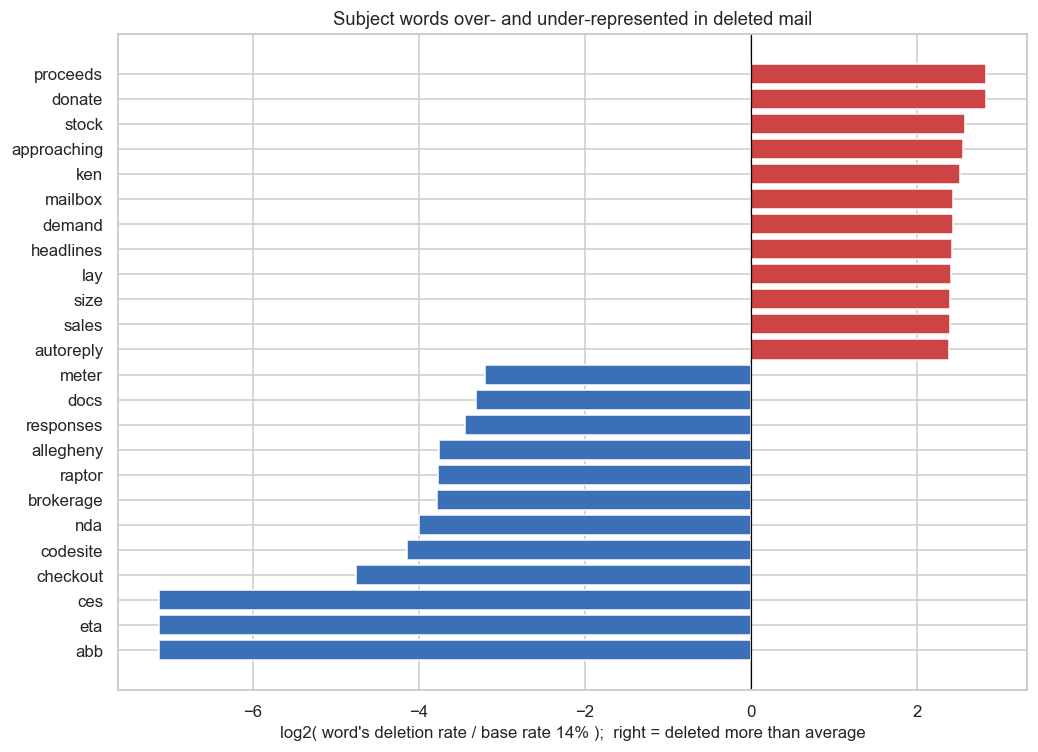

most over-deleted subject words:
       word  total  del_rate
  autoreply    300  0.733333
      sales   1580  0.737975
       size    307  0.739414
        lay   1544  0.744819
  headlines    345  0.750725
     demand   1538  0.754876
    mailbox    294  0.758503
        ken   1410  0.804255
approaching    258  0.821705
      stock   1400  0.840000
     donate   1125  0.998222
   proceeds   1125  0.999111


In [14]:
del_mask = msg["folder_group"].eq("deleted")
base = del_mask.mean()
dc, kc = Counter(), Counter()
for s, d in zip(msg["canon_subject"].fillna(""), del_mask):
    for w in set(WORD.findall(s.lower())):
        if w in STOP or len(w) <= 2:
            continue
        (dc if d else kc)[w] += 1

rowsf = []
for w in set(dc) | set(kc):
    tot = dc[w] + kc[w]
    if tot < 200:
        continue
    r = dc[w] / tot
    rowsf.append((w, tot, r, np.log2((r + 1e-3) / (base + 1e-3))))
wf = pd.DataFrame(rowsf, columns=["word", "total", "del_rate", "log2ratio"]).sort_values("log2ratio")
sel = pd.concat([wf.head(12), wf.tail(12)])

fig, ax = plt.subplots(figsize=(9.6, 7))
colors = ["#c44" if v > 0 else "#3b6fb6" for v in sel["log2ratio"]]
ax.barh(sel["word"], sel["log2ratio"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel(f"log2( word's deletion rate / base rate {base:.0%} );  right = deleted more than average")
ax.set_title("Subject words over- and under-represented in deleted mail")
fig.tight_layout()
fig.savefig(PLOTS / "f2_deletion_topic_preference.png", dpi=140, bbox_inches="tight")
plt.show()

print("most over-deleted subject words:")
print(wf.tail(12)[["word", "total", "del_rate"]].to_string(index=False))

**What it shows.** Deletion is strongly topic-dependent. On the clean data the
base rate is about fourteen percent of messages (up from the raw 10%, because
the kept folders held more of the duplicate copies that dedup removed), and the
subjects far above that line are dominated by one human event. The words
`proceeds`, `donate`, `stock`, `demand`, `ken` and `lay` are deleted almost
every time they appear, because they belong to one mass-protest campaign:
thousands of near-identical messages headed roughly 'demand Ken Lay donate the
proceeds from his Enron stock sales', dumped into Ken Lay's mailbox after the
collapse and swept straight into his deleted folder. The rest of the over-
deleted list is automated machine traffic such as `headlines`, `mailbox`
(over-quota warnings) and `approaching`. At the other end the under-deleted
words are the deal and counterparty vocabulary people kept: `nda`, `raptor`,
`abb`, `allegheny`, `brokerage`. Employees discarded noise and protest and
filed the business, so the deleted folders are emphatically not a random
sample.

## G. Did people leaving drive deletion?

The last and most speculative point: is a person leaving the company a reason
their mail was deleted? The corpus does not record termination dates, so a
clean test is not possible, but there is a usable proxy. The last month in
which a mailbox shows any activity stands in for when that person stopped using
it. If departures drove deletion we would expect a mailbox's deletions to bunch
up in its final stretch, more than its ordinary mail does. The plot tests
exactly that, and reports the answer whether or not it supports the idea.

mailboxes tested: 119
median concentration ratio (last 60 days): 1.65
mailboxes that delete more near the end (ratio>1): 76%


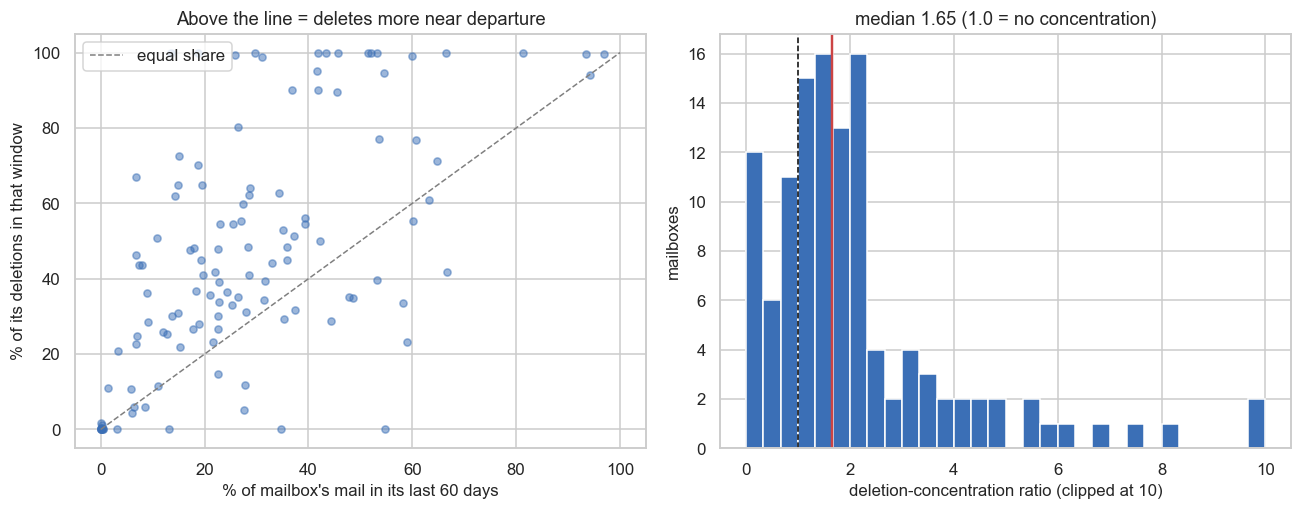

In [15]:
own = mt.copy()
own["deleted"] = own["folder_group"].eq("deleted")
last = own.groupby("mailbox_owner")["date"].max()

res = []
for u, sub in own.groupby("mailbox_owner"):
    if len(sub) < 200 or sub["deleted"].sum() < 20:
        continue
    win_start = last[u] - pd.Timedelta(days=60)
    in_win = sub["date"] >= win_start
    mail_share = in_win.mean()
    del_share = (in_win & sub["deleted"]).sum() / sub["deleted"].sum()
    if mail_share > 0:
        res.append((u, mail_share, del_share, del_share / mail_share))
dd = pd.DataFrame(res, columns=["user", "mail_share", "del_share", "ratio"]).dropna()
print(f"mailboxes tested: {len(dd)}")
print(f"median concentration ratio (last 60 days): {dd['ratio'].median():.2f}")
print(f"mailboxes that delete more near the end (ratio>1): {(dd['ratio'] > 1).mean():.0%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(dd["mail_share"] * 100, dd["del_share"] * 100, s=22, alpha=0.5, color="#3b6fb6")
lim = max(dd["mail_share"].max(), dd["del_share"].max()) * 100
axes[0].plot([0, lim], [0, lim], "--", color="gray", lw=1, label="equal share")
axes[0].set_xlabel("% of mailbox's mail in its last 60 days")
axes[0].set_ylabel("% of its deletions in that window")
axes[0].set_title("Above the line = deletes more near departure")
axes[0].legend(loc="upper left")
axes[1].hist(dd["ratio"].clip(upper=10), bins=30, color="#3b6fb6")
axes[1].axvline(1, color="black", ls="--", lw=1)
axes[1].axvline(dd["ratio"].median(), color="#c44", lw=1.6)
axes[1].set_xlabel("deletion-concentration ratio (clipped at 10)")
axes[1].set_ylabel("mailboxes")
axes[1].set_title(f"median {dd['ratio'].median():.2f} (1.0 = no concentration)")
fig.tight_layout()
fig.savefig(PLOTS / "g1_departure_vs_deletion.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** On its face the signal is strong and points the way the
reviewer guessed: deletions are end-loaded. Across the 119 testable mailboxes
the median concentration ratio is 1.65, and 76% of them delete a larger share
of their mail in their last sixty active days than they send or receive there,
so the cloud sits mostly above the equal-share line. Taken at face value that
says people clear mail out as they head for the door.

It cannot be read that cleanly, though, because of how the deleted folder
works. `deleted_items` is a live buffer that Outlook and its users empty
periodically, so whatever deletions survive to the 2002 snapshot are
disproportionately the recent ones; older deletions were already purged. That
alone produces an end-loaded pattern for almost every mailbox, whether or not
the person ever left. The last-activity proxy is also not a real termination
date. So the honest verdict is that the data is consistent with departures
prompting a clean-out, but the rolling-buffer artefact offers an equally good
explanation, and these headers cannot separate the two. The firmer result
remains section F's: deletion is driven by topic, dropping machine noise and
protest mail while keeping the business.

## H. Conversation threads, now that we can build them

The week-three notebook could not look at conversations at all: the release has
no `In-Reply-To` or `References` headers, so there was nothing to chain replies
with. The cleaning step reconstructs threads from a shared normalised subject
plus an overlapping participant within a 30-day window, which gives 40,306
multi-message threads to work with. Two questions the originals could never
reach: how fast people reply, and how big conversations get.

multi-message threads: 40,306
reply latency (h): median 3.0, p25 0.3, p75 23.7
replies within 1h: 37%; within 24h: 76%


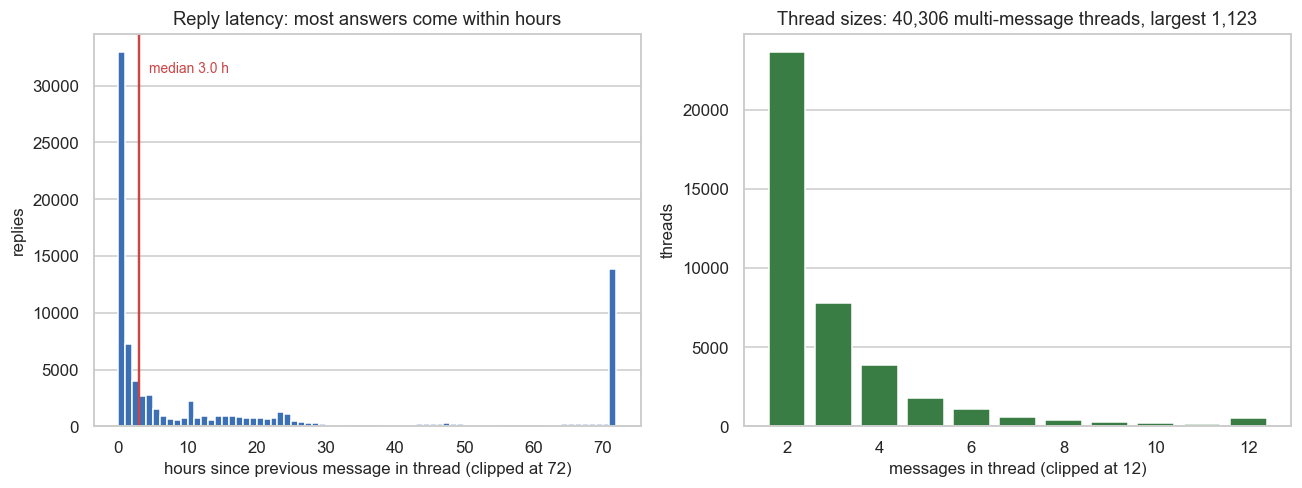

In [16]:
thr = mt.sort_values(["thread_id", "date"]).copy()
thr["gap_h"] = thr.groupby("thread_id")["date"].diff().dt.total_seconds() / 3600
lat = thr.loc[thr["thread_position"] > 1, "gap_h"].dropna()
lat = lat[lat >= 0]
sizes = msg.groupby("thread_id").size()
multi = sizes[sizes > 1]
print(f"multi-message threads: {len(multi):,}")
print(f"reply latency (h): median {lat.median():.1f}, "
      f"p25 {lat.quantile(.25):.1f}, p75 {lat.quantile(.75):.1f}")
print(f"replies within 1h: {(lat<1).mean():.0%}; within 24h: {(lat<24).mean():.0%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].hist(lat.clip(upper=72), bins=72, color="#3b6fb6")
axes[0].axvline(lat.median(), color="#c44", lw=1.6)
axes[0].text(lat.median() + 1.5, axes[0].get_ylim()[1] * 0.9,
             f"median {lat.median():.1f} h", fontsize=9, color="#c44")
axes[0].set_xlabel("hours since previous message in thread (clipped at 72)")
axes[0].set_ylabel("replies")
axes[0].set_title("Reply latency: most answers come within hours")
axes[0].grid(axis="x", visible=False)

vc = multi.clip(upper=12).value_counts().sort_index()
axes[1].bar(vc.index, vc.values, color="#3a7d44")
axes[1].set_xlabel("messages in thread (clipped at 12)")
axes[1].set_ylabel("threads")
axes[1].set_title(f"Thread sizes: {len(multi):,} multi-message threads, "
                  f"largest {int(sizes.max()):,}")
axes[1].grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(PLOTS / "h1_threads.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** Enron mail was answered fast. Half of all replies land within
about three hours of the message before them, a quarter within twenty minutes,
and three quarters inside a day; the long tail past that is the slow-burn
threads that resume after a pause. Conversation sizes follow the usual heavy
skew: most threads are a single back-and-forth pair, the count falls off
steeply with each extra message, and only a few thousand run long. The one
genuinely huge thread (over a thousand messages) is the post-collapse protest
campaign from section F, which is a blast rather than a conversation. The
reconstruction is a heuristic standing in for the missing headers, so a
slow-burn exchange that pauses more than a month is split into two, but for
reply-speed and thread-size description that bias is small.

## Where this leaves us

Run on the cleaned data, the review points resolve cleanly and a few of the
week-three numbers move. The activity heatmap separates volume from shape and
colours empty cells white. The completeness question has a concrete answer: the
517,401 files are 252,022 distinct messages, small in size, spanning 1999 to
2002, complete on identity and timing but stripped of the threading headers,
and drawn from 150 mailboxes that see only about a sixth of the internal people
they correspond with.

Three findings changed once duplication and split identities were removed,
and they are worth carrying forward. The folder mix inverts: project and topic
folders are not the largest block, they are mostly re-filed copies, and once
deduplicated `sent` and `inbox` dominate. Mailbox size re-ranks: the raw
'largest mailbox' was an artifact of how heavily one folder was duplicated.
And the reciprocal social core is far denser than the raw graph suggested,
because collapsing address spellings to people reconnects edges, though that
density is partly a property of a hand-picked set of central people rather than
a natural office structure.

The new material the cleaning unlocked is threads. Enron mail was answered
fast, a median of about three hours and three quarters within a day, and
conversation sizes are heavily skewed, mostly short with a long thin tail. The
California and EES content, now measured on the full corpus instead of a 25k
sample, holds its earlier shape but on far firmer ground.

The recurring caveat is still coverage. Every count, edge and rate describes
150 well-captured mailboxes, not Enron as a whole, and the reconstructed
threads are a heuristic standing in for headers that no longer exist. The full
cleaning procedure and its limits are in `eda-5/DATASET_CLEANING.md`; this
notebook is the summary built on top of it.